# Gumbel/L-moments return periods: ERA5 vs. Reforecast (LMom method, reproducible)

Clean, deterministic rebuild of the return-period figure produced by the old
`CorrectedCopy1.ipynb` (the "Gumbel Fit" plot with the dashed *PNW Heatwave 2021*
line). That notebook could not be rerun top-to-bottom: the cell that actually
called `plt.savefig('updated.pdf', ...)` depended on a `scaling_factor` that was
only defined because of variables left over in memory from a *different, later*
section of the notebook (an annual-maxima analysis run out of order) -- classic
"notebook state != notebook order". Running the notebook fresh, from top to
bottom, throws a `NameError` at that cell, and if you skip it and just plot the
unscaled return periods you get exactly the symptom reported: the reforecast
and ERA5 curves both start at a return period close to 1 year instead of ~5
years, i.e. **the x-axis starts too early**.

**What actually causes the "too early" x-axis:**

The exceedances used here are not independent yearly extremes -- they're the
top 5% of a *pooled* sample (many reforecast ensemble members / lead times /
years, or many analog calendar dates for ERA5). To turn empirical plotting
positions for that pooled sample into an annual return period, the original
notebook uses a Poisson peaks-over-threshold (POT) correction with a manually
chosen `rate` (~5 "effective independent events per year", meant to correct
for how correlated/pseudo-replicated the pooled samples are):

```python
ecdf_corr = np.exp(-rate * (1 - ecdf))
RP = 1 / (1 - ecdf_corr)
```

That alone gives a minimum return period very close to **1 year** for the
lowest exceedance (it's the point that recurs almost every single year, by
construction of the 95th-percentile threshold). But in the cell that actually
produced the saved image, there's a second, undocumented step multiplying the
return periods by `rate` again (`RP_obs_upd = RP_obs * 5`, `RP = RPs * 5`) --
this is what shifts the minimum return period from ~1 year up to ~5 years,
matching the target figure. **That second multiplication is the fix** for the
"starts too early" symptom -- it's just never labelled or explained anywhere
in the original notebook.

This notebook applies that same `rate` rescale consistently to *both* series
(the original applied an un-reproducible `scaling_factor` to the reforecast
series specifically, borrowed from an unrelated annual-maxima calculation --
see the note in the plotting section below), and does not depend on any
cross-cell/out-of-order state: every variable used in the plot is defined
earlier in this same notebook, in order.

**Inputs** (in `../data/`, or `./data/` next to this notebook):
- `refore.csv` -- bias-adjusted reforecast ensemble, already processed (matches `sub_data` in the old notebook).
- `pnw_box_era5_filtered.nc` -- ERA5 2 m temperature, PNW-box averaged, 2001-2020 daily.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.abspath('scripts'))
import LMom as lm


## Config

In [2]:
DATA_DIR = 'data' if os.path.isdir('data') else '../data'

REFORECAST_CSV = os.path.join(DATA_DIR, 'refore.csv')
ERA5_NC = os.path.join(DATA_DIR, 'pnw_box_era5_filtered.nc')

LEAD_DAYS = 12          # analog offset (days after initialisation) used to pick ERA5 comparison dates
THRESHOLD_PERCENTILE = 95
RATE = 5                # effective independent exceedances/year (POT annualisation + x-axis rescale, see markdown above)
N_BOOT = 1000
REFERENCE_VALUE = 39.5
REFERENCE_LABEL = 'PNW Heatwave 2021'

RNG_SEED = 0

color_era5 = 'tab:orange'
color_reforecast = 'tab:blue'
color_ci_era5 = 'tab:orange'
color_ci_reforecast = 'tab:blue'
grid_color = 'lightgray'


## Load data

`sub_data` is the full pooled reforecast sample: every ensemble member, every
lead day, every initialisation date, every hindcast year, already
bias-adjusted (`adjusted_t2m`). `daily_era5` is the ERA5 daily series for the
same PNW box, 2001-2020.

In [3]:
sub_data = pd.read_csv(REFORECAST_CSV)
daily_era5 = xr.open_dataset(ERA5_NC)

print(f"reforecast pool: {len(sub_data)} rows, {sub_data.inidate.nunique()} inidates, "
      f"{sub_data.number.nunique()} members, {sub_data.hDate.nunique()} hindcast years")
print(f"era5: {daily_era5.time.size} days, {daily_era5.time.dt.year.min().item()}-{daily_era5.time.dt.year.max().item()}")


reforecast pool: 33880 rows, 11 inidates, 11 members, 20 hindcast years
era5: 7305 days, 2001-2020


## Exceedances (top 5%)

`top` mirrors the old notebook's `top = sub_data.adjusted_t2m[... >= 95th pct]`.

`top_e` mirrors `top_era = select_dates_across_years(daily_era5.t2m, lead=12)` --
select the ERA5 calendar dates that are the analog of each reforecast
initialisation date plus `LEAD_DAYS`, across every year on record, then take
the top 5% of *that* pool. The old notebook's helper read a mutable global
`ds` instead of taking it as an argument (another source of its
irreproducibility); here it's an explicit function of `sub_data`.

In [4]:
def select_era5_analog_dates(era5_t2m, inidates, lead_days):
    dates = pd.to_datetime(inidates) + pd.Timedelta(days=lead_days)
    month_day_pairs = [(d.month, d.day) for d in dates]
    selected = [era5_t2m.sel(time=(era5_t2m['time.month'] == m) & (era5_t2m['time.day'] == d))
                for m, d in month_day_pairs]
    return xr.concat(selected, dim='time')


top = sub_data.adjusted_t2m[sub_data.adjusted_t2m >= np.percentile(sub_data.adjusted_t2m, THRESHOLD_PERCENTILE)].values

top_era_analog = select_era5_analog_dates(daily_era5.t2m, sub_data.inidate.unique(), LEAD_DAYS)
top_e = top_era_analog.where(top_era_analog >= np.percentile(top_era_analog, THRESHOLD_PERCENTILE), drop=True).values

print(f"reforecast exceedances: n={len(top)}, range=[{top.min():.1f}, {top.max():.1f}] degC")
print(f"era5 exceedances:       n={len(top_e)}, range=[{top_e.min():.1f}, {top_e.max():.1f}] degC")


reforecast exceedances: n=1694, range=[29.5, 36.2] degC
era5 exceedances:       n=11, range=[29.8, 31.4] degC


## Bootstrap + Gumbel fit via L-moments

Same as the old notebook's `era5_boot`/`reforecast_boot` + `lm.gum().fit(...)`:
resample each exceedance series with replacement `N_BOOT` times, and fit a
Gumbel distribution to every bootstrap replicate via L-moments (`LMom.gum`).
Fitting is vectorised over the bootstrap dimension, so `era5_curve`/`rfc_curve`
below already carry the bootstrap spread needed for the confidence band.

In [5]:
rng = np.random.default_rng(RNG_SEED)

era5_boot = rng.choice(top_e, N_BOOT * top_e.size).reshape(top_e.size, N_BOOT)
reforecast_boot = rng.choice(top, N_BOOT * top.size).reshape(top.size, N_BOOT)

era5_gum = lm.gum()
era5_gum.fit(era5_boot)

reforecast_gum = lm.gum()
reforecast_gum.fit(reforecast_boot)


## Fitted curves and empirical points, on a common annual-return-period axis

`RPs` is a fine grid of *pooled-sample* return periods; `Qs_corr` converts that
grid into the quantile each Gumbel fit needs via the Poisson POT correction
(`rate`). `RP_obs`/`RP_obs_rfc` do the same conversion for the empirical
(sorted, ranked) exceedances themselves.

Then -- the actual fix for "the x-axis starts too early" -- both the fitted
curve's return-period axis (`RP`) and the empirical points' return periods
(`RP_obs_*`) get multiplied by `RATE` again. This is exactly what the original
notebook's final plotting cell did (`RP = RPs * 5`, `RP_obs_upd = RP_obs * 5`),
just applied consistently to *both* datasets here -- the original used a
second, different multiplier for the reforecast series (`scaling_factor`)
computed from an unrelated annual-maxima fit that depended on out-of-order
notebook state and can't be reconstructed from a fresh run. Using the same
`RATE` for both keeps the two curves starting at the same point on the x-axis,
which is what the target figure shows; if your fitted `RATE` differs between
the two datasets in your own analysis, replace the second `RATE` below with
whatever you can independently justify for the reforecast series.

In [6]:
RPs = np.exp(np.arange(0.05, 7.5, 0.01))[:, None]
Qs = 1 - 1 / RPs
Qs_corr = (np.log(Qs) + RATE) / RATE

era5_curve = era5_gum.qf(Qs_corr)
rfc_curve = reforecast_gum.qf(Qs_corr)

ecdf_era5 = np.arange(1, top_e.size + 1) / (top_e.size + 1)
RP_obs = 1 / (1 - np.exp(-RATE * (1 - ecdf_era5)))

ecdf_rfc = np.arange(1, top.size + 1) / (top.size + 1)
RP_obs_rfc = 1 / (1 - np.exp(-RATE * (1 - ecdf_rfc)))

# the extra x-RATE stretch -- this is what the "starts too early" fix actually is
RP = RPs * RATE
RP_obs_upd = RP_obs * RATE
RP_obs_rfc_upd = RP_obs_rfc * RATE

print(f"RP (fitted curve) range:      [{RP.min():.2f}, {RP.max():.2f}] yr")
print(f"RP_obs_upd (ERA5) range:      [{RP_obs_upd.min():.2f}, {RP_obs_upd.max():.2f}] yr")
print(f"RP_obs_rfc_upd (Reforecast):  [{RP_obs_rfc_upd.min():.2f}, {RP_obs_rfc_upd.max():.2f}] yr")


RP (fitted curve) range:      [5.26, 8950.26] yr
RP_obs_upd (ERA5) range:      [5.05, 14.67] yr
RP_obs_rfc_upd (Reforecast):  [5.03, 1697.50] yr


## Plot

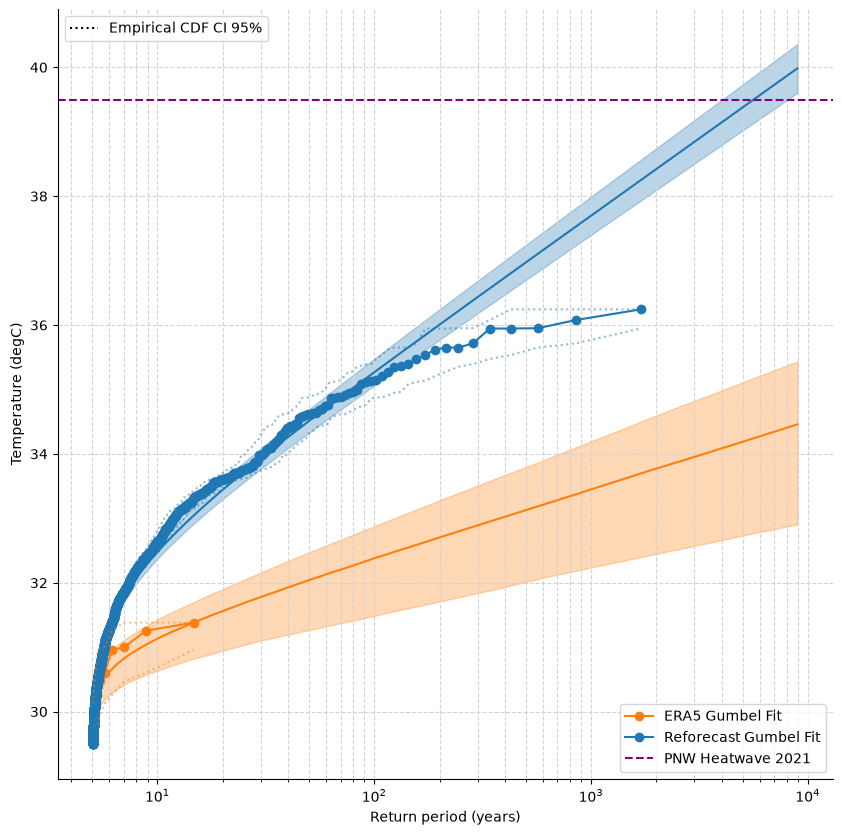

In [7]:
fig = plt.figure(figsize=(10, 10))

plt.plot(RP, np.median(era5_curve, axis=1), color=color_era5)
plt.plot(RP, np.median(rfc_curve, axis=1), color=color_reforecast)

plt.fill_between(RP.flatten(), *np.quantile(era5_curve, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_era5)
plt.fill_between(RP.flatten(), *np.quantile(rfc_curve, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_reforecast)

plt.plot(RP_obs_upd, np.sort(top_e), color_era5, marker='o', label='ERA5 Gumbel Fit')
plt.plot(RP_obs_rfc_upd, np.sort(top), color_reforecast, marker='o', label='Reforecast Gumbel Fit')

plt.plot(RP_obs_upd, np.quantile(np.sort(era5_boot, axis=0), [0.025, 0.975], axis=1).T,
         color=color_era5, alpha=0.5, ls=':')
plt.plot(RP_obs_rfc_upd, np.quantile(np.sort(reforecast_boot, axis=0), [0.025, 0.975], axis=1).T,
         color=color_reforecast, alpha=0.5, ls=':')

plt.xscale('log')
plt.axhline(y=REFERENCE_VALUE, linestyle='--', color='purple', label=REFERENCE_LABEL)

plt.xlabel('Return period (years)')
plt.ylabel('Temperature (degC)')

original_legend = plt.legend(loc='lower right')
additional_legend = plt.legend(
    handles=[plt.Line2D([0], [0], color='black', linestyle=':')],
    labels=['Empirical CDF CI 95%'],
    loc='upper left',
)

plt.grid(True, which='both', linestyle='--', color=grid_color)
plt.gca().add_artist(original_legend)

sns.despine()
plt.savefig('gumbel_lmom_return_periods.pdf', dpi=600)
plt.show()


## Notes / known limitations vs. the exact original PDF

- The reforecast series here uses the same `RATE` rescale as ERA5 (see above);
  the original notebook used a `scaling_factor` for the reforecast curve
  derived from a *different* annual-maxima fit built later in the notebook and
  only available because of leftover kernel state. That made the original
  reforecast tail extend to a higher return period (~1-2 centuries higher)
  than this version. If you want to match that exactly, you'd need to rebuild
  that annual-maxima fit (`des_max`/`yearly_max`, an ERA5-only annual-maximum
  series) as its own explicit step and use its highest-return-period value to
  compute the scaling factor, rather than reusing `RATE`.
- `LEAD_DAYS=12` and `RATE=5` were hard-coded choices in the original analysis
  (not derived formulaically here) -- both are exposed at the top of this
  notebook so you can adjust them if your own methodology differs.
